In [ ]:
import sys
sys.path.insert(0, '..')

# =====================================================
# EXPLORATORY ANALYSIS: METRICS OVER TIME
# =====================================================
# This notebook analyzes how metrics changes over time
# for different player types, with 95% confidence intervals.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Import utility functions from plot_utilities
from plot_utilities import (
    load_turn_data,
    setup_notebook_display,
    plot_bar_chart,
    plot_forest_plot,
    prepare_coefficient_data,
    plot_metric_over_time  # Generalized function for any metric
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(12, 6))

# Load turn data with player type mapping automatically applied
turn_df = load_turn_data('../models/output/grouped_mlp_predictions.csv', condition_exclude=[])

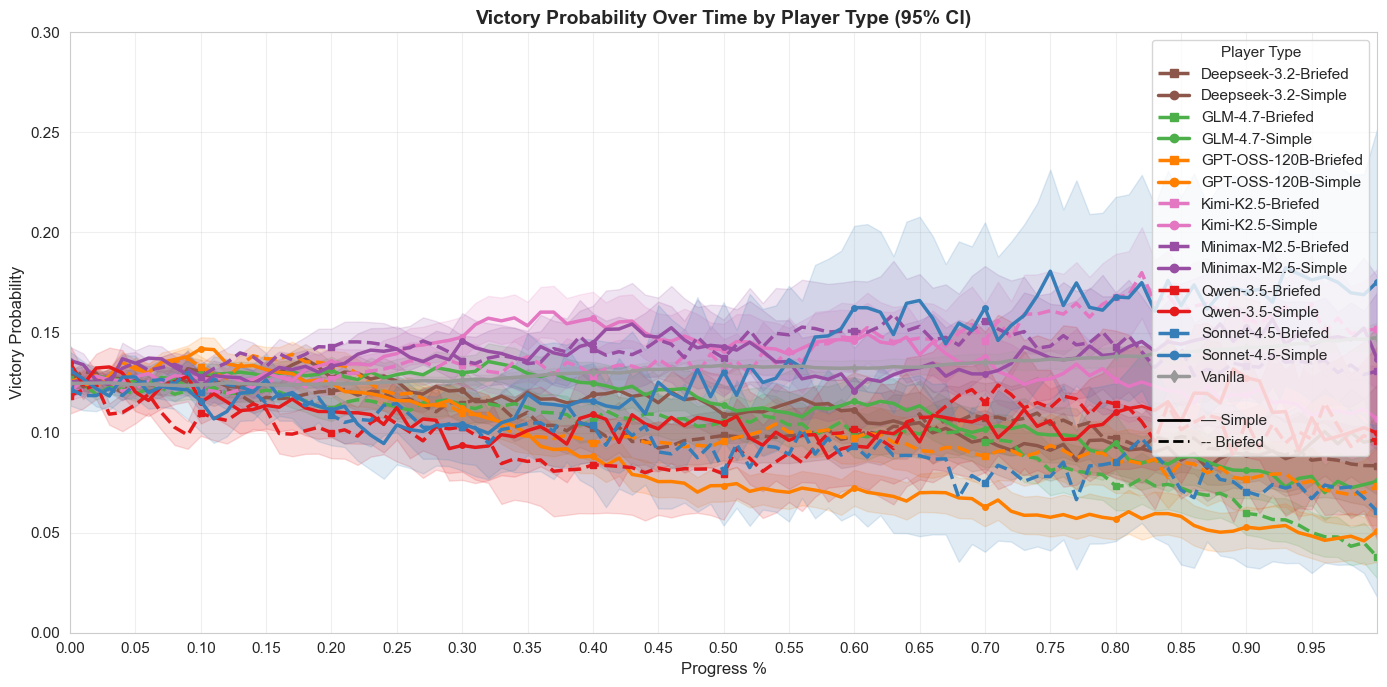

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,0.106,0.154,0.0,0.993,-0.034751,-0.065
Deepseek-3.2-Simple,49080,0.111,0.156,0.0,0.998,-0.046846,-0.087
GLM-4.7-Briefed,75725,0.098,0.139,0.0,0.998,-0.070076,-0.146
GLM-4.7-Simple,75725,0.111,0.151,0.0,0.993,-0.059702,-0.114
GPT-OSS-120B-Briefed,59705,0.102,0.148,0.0,0.980,-0.063092,-0.123
GPT-OSS-120B-Simple,59705,0.086,0.111,0.0,0.925,-0.100058,-0.260
Kimi-K2.5-Briefed,58275,0.141,0.192,0.0,0.997,0.046336,0.070
Kimi-K2.5-Simple,58275,0.135,0.171,0.0,0.993,-0.016979,-0.029
Minimax-M2.5-Briefed,31460,0.141,0.189,0.0,0.991,0.005665,0.009
Minimax-M2.5-Simple,31460,0.138,0.196,0.0,0.995,0.012252,0.018


In [ ]:
fig, ax = plot_metric_over_time(
    turn_df,
    metric_calculation=lambda df: df['predicted_win_probability'],
    title="Victory Probability Over Time by Player Type",
    ylabel="Victory Probability",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, 0.3)
)

In [ ]:
# =====================================================
# PLAYER STRENGTH: QUADRATIC WEIGHTED AVERAGE
# =====================================================
# Calculate player strength using quadratic weights that emphasize late-game performance
# Uses log-odds transformation for averaging to handle extreme probabilities properly

# Define logit and inverse logit transformations
def logit(p):
    """Transform probability to log-odds space"""
    # Clip to avoid log(0) or log of negative numbers
    p_clipped = np.clip(p, 1e-5, 1 - 1e-5)
    return np.log(p_clipped / (1 - p_clipped))

def inv_logit(x):
    """Transform log-odds back to probability space"""
    return 1 / (1 + np.exp(-x))


# First, average log-odds within each turn_progress group
# This handles cases where multiple turns have the same rounded turn_progress value
turn_progress_avg = turn_df[turn_df['turn_progress'] > 0.2].groupby(['game_id', 'player_id', 'turn_progress']).agg({
    'predicted_win_probability': 'mean',
    'player_type': 'first',
    'experiment': 'first',
    'is_winner': 'last',
    'civilization': 'first'
}).reset_index()
# Calculate weights based on unique turn_progress values
# Weight = turn_progress, where turn_progress ranges from 0 to 1
turn_progress_avg['quadratic_weight'] = turn_progress_avg['turn_progress']

# Calculate weighted average of log-odds for each player
weighted_strength = []

for (game_id, player_id), group in turn_progress_avg.groupby(['game_id', 'player_id']):
    # Calculate weighted average across unique turn_progress values in
    weights = group['quadratic_weight']
    probability = group['predicted_win_probability']
    weighted_avg_probability = (weights * probability).sum() / weights.sum()
    
    # Get player type and other info
    player_type = group['player_type'].iloc[0]
    civilization = group['civilization'].iloc[0]
    experiment = group['experiment'].iloc[0]
    is_winner = group['is_winner'].iloc[-1]  # Winner status from final turn
    
    weighted_strength.append({
        'game_id': game_id,
        'player_id': player_id,
        'player_type': player_type,
        'civilization': civilization,
        'experiment': experiment,
        'weighted_strength': weighted_avg_probability,
        'is_winner': is_winner
    })

strength_df = pd.DataFrame(weighted_strength)

In [ ]:
# =====================================================
# RELATIVE STRENGTH: STRENGTH RELATIVE TO GAME LEADER
# =====================================================
# Calculate each player's strength relative to the strongest player in their game

# For each game, find the maximum weighted strength
game_max_strength = strength_df.groupby('game_id')['weighted_strength'].max().reset_index()
game_max_strength.columns = ['game_id', 'max_weighted_strength']

# Merge back with the strength dataframe
strength_df = strength_df.merge(game_max_strength, on='game_id')

# Calculate relative strength as a ratio
strength_df['relative_strength'] = strength_df['weighted_strength'] / strength_df['max_weighted_strength']

player_level = strength_df.groupby(['player_type']).agg({
    'player_type': 'first',
    'relative_strength': 'mean',
})
print(player_level)

                               player_type  relative_strength
player_type                                                  
Deepseek-3.2-Briefed  Deepseek-3.2-Briefed           0.196181
Deepseek-3.2-Simple    Deepseek-3.2-Simple           0.193289
GLM-4.7-Briefed            GLM-4.7-Briefed           0.172540
GLM-4.7-Simple              GLM-4.7-Simple           0.187658
GPT-OSS-120B-Briefed  GPT-OSS-120B-Briefed           0.169250
GPT-OSS-120B-Simple    GPT-OSS-120B-Simple           0.139279
Kimi-K2.5-Briefed        Kimi-K2.5-Briefed           0.289480
Kimi-K2.5-Simple          Kimi-K2.5-Simple           0.257433
Minimax-M2.5-Briefed  Minimax-M2.5-Briefed           0.261126
Minimax-M2.5-Simple    Minimax-M2.5-Simple           0.254738
Qwen-3.5-Briefed          Qwen-3.5-Briefed           0.203103
Qwen-3.5-Simple            Qwen-3.5-Simple           0.208922
Sonnet-4.5-Briefed      Sonnet-4.5-Briefed           0.155096
Sonnet-4.5-Simple        Sonnet-4.5-Simple           0.287125
Vanilla 

In [ ]:
winner_df = strength_df[strength_df['is_winner'] == 1]

# Display summary statistics
print(f"Winner's Strength Statistics:")
print(f"  Mean: {winner_df['relative_strength'].mean():.3f}")
print(f"  Median: {winner_df['relative_strength'].median():.3f}")
print(f"  Std Dev: {winner_df['relative_strength'].std():.3f}")
print(f"  Min: {winner_df['relative_strength'].min():.3f}")
print(f"  Max: {winner_df['relative_strength'].max():.3f}")

Winner's Strength Statistics:
  Mean: 0.881
  Median: 1.000
  Std Dev: 0.242
  Min: 0.036
  Max: 1.000


In [ ]:
# =====================================================
# OUTLIERS: WINNERS WITH MINIMAL RELATIVE STRENGTH
# =====================================================
# Display winners who won despite having low relative strength (underdogs)

print("\n" + "=" * 60)
print("OUTLIERS: Winners with Minimal Relative Strength")
print("=" * 60)

winner_df = strength_df[strength_df['is_winner'] == 1]
# Get bottom 10 winners by relative strength
outliers = winner_df.nsmallest(10, 'relative_strength')[
    ['game_id', 'player_id', 'player_type', 'civilization', 'experiment', 
     'relative_strength', 'weighted_strength', 'max_weighted_strength']
].reset_index(drop=True)

# Display with formatted output
print(f"\nTop 10 'Underdog' Winners (lowest relative strength):\n")
for idx, row in outliers.iterrows():
    print(f"{idx+1}. Game {row['game_id']}, Player {row['player_id']}")
    print(f"   Player Type: {row['player_type']}")
    print(f"   Civilization: {row['civilization']}")
    print(f"   Experiment: {row['experiment']}")
    print(f"   Relative Strength: {row['relative_strength']:.3f}")
    print(f"   Weighted Strength: {row['weighted_strength']:.4f}")
    print(f"   Game Leader Strength: {row['max_weighted_strength']:.4f}")
    print()


OUTLIERS: Winners with Minimal Relative Strength

Top 10 'Underdog' Winners (lowest relative strength):

1. Game ff11198e-eac8-4f33-80bd-a7b2ca975dc0, Player 4
   Player Type: GPT-OSS-120B-Simple
   Civilization: Germany
   Experiment: 2026-staff-standard
   Relative Strength: 0.036
   Weighted Strength: 0.0265
   Game Leader Strength: 0.7413

2. Game 567c5b26-a371-47b4-b68a-b5056c806696, Player 5
   Player Type: Vanilla
   Civilization: Germany
   Experiment: observe-vanilla-standard
   Relative Strength: 0.069
   Weighted Strength: 0.0391
   Game Leader Strength: 0.5705

3. Game c6817e9a-d305-43ee-9648-d15a7eca8009, Player 1
   Player Type: Vanilla
   Civilization: Spain
   Experiment: observe-vanilla-standard
   Relative Strength: 0.069
   Weighted Strength: 0.0462
   Game Leader Strength: 0.6647

4. Game f051d432-aab6-4a4e-8c73-4c713fc940ca, Player 7
   Player Type: Vanilla
   Civilization: Egypt
   Experiment: observe-vanilla-standard
   Relative Strength: 0.097
   Weighted Stren

In [ ]:
# Adjust all winners to have relative_strength = 0.0 (The best)

# For each winner, set relative_strength to 1.0 and adjust weighted_strength
for idx, row in strength_df[strength_df['is_winner'] == 1].iterrows():
    if row['relative_strength'] < 1.0:
        # Update weighted_strength to maintain consistency (+0.001 to make sure it is ranked #1)
        strength_df.at[idx, 'weighted_strength'] = row['max_weighted_strength'] + 0.001
        strength_df.at[idx, 'relative_strength'] = 1.0

player_level = strength_df.groupby(['player_type']).agg({
    'player_type': 'first',
    'relative_strength': 'mean',
})
print(player_level)

                               player_type  relative_strength
player_type                                                  
Deepseek-3.2-Briefed  Deepseek-3.2-Briefed           0.196181
Deepseek-3.2-Simple    Deepseek-3.2-Simple           0.198183
GLM-4.7-Briefed            GLM-4.7-Briefed           0.175117
GLM-4.7-Simple              GLM-4.7-Simple           0.191788
GPT-OSS-120B-Briefed  GPT-OSS-120B-Briefed           0.183708
GPT-OSS-120B-Simple    GPT-OSS-120B-Simple           0.158412
Kimi-K2.5-Briefed        Kimi-K2.5-Briefed           0.311000
Kimi-K2.5-Simple          Kimi-K2.5-Simple           0.262702
Minimax-M2.5-Briefed  Minimax-M2.5-Briefed           0.279226
Minimax-M2.5-Simple    Minimax-M2.5-Simple           0.270378
Qwen-3.5-Briefed          Qwen-3.5-Briefed           0.236353
Qwen-3.5-Simple            Qwen-3.5-Simple           0.229327
Sonnet-4.5-Briefed      Sonnet-4.5-Briefed           0.168996
Sonnet-4.5-Simple        Sonnet-4.5-Simple           0.319760
Vanilla 

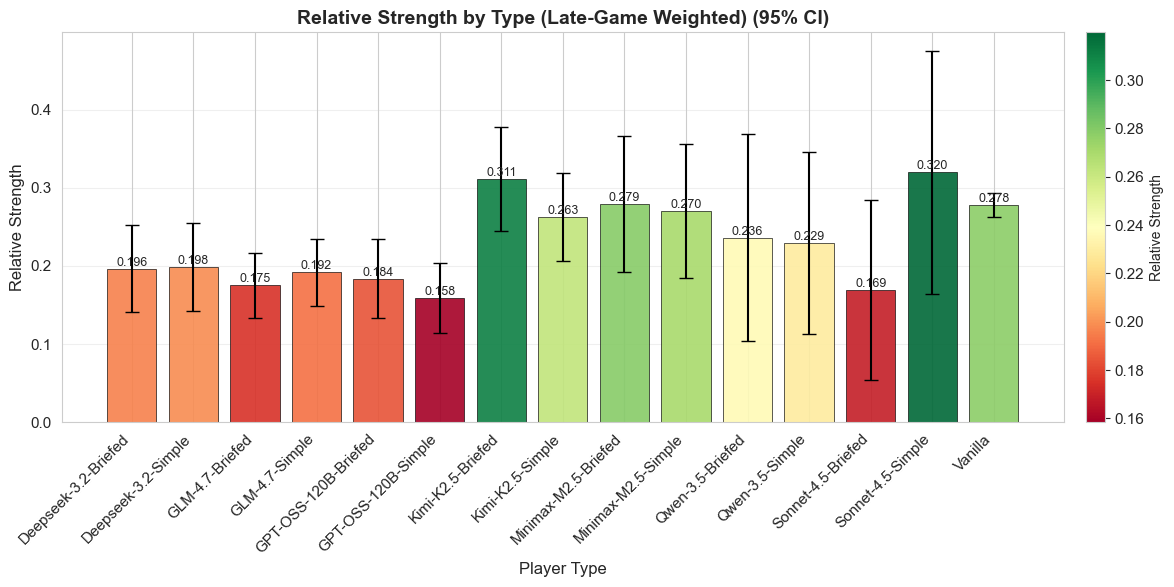

,Mean,Std,N
Deepseek-3.2-Briefed,0.196181,0.304237,115
Deepseek-3.2-Simple,0.198183,0.307804,115
GLM-4.7-Briefed,0.175117,0.282515,179
GLM-4.7-Simple,0.191788,0.294786,179
GPT-OSS-120B-Briefed,0.183708,0.306967,142
GPT-OSS-120B-Simple,0.158412,0.272066,142
Kimi-K2.5-Briefed,0.311000,0.396009,137
Kimi-K2.5-Simple,0.262702,0.337837,137
Minimax-M2.5-Briefed,0.279226,0.385872,75
Minimax-M2.5-Simple,0.270378,0.377593,75


In [ ]:
# Plot bar chart of average relative strength by player type
plot_bar_chart(
    strength_df,
    category_col='player_type',
    value_col='relative_strength',
    use_percentage=False,
    xlabel='Player Type',
    ylabel='Relative Strength',
    title='Relative Strength by Type (Late-Game Weighted)',
    show_error_bars=True,
    confidence_level=0.95,
    value_format='{:.3f}',
    rotation=45,
    colormap='RdYlGn',
    figsize=(12, 6)
)

In [ ]:
# =====================================================
# FIT LINEAR REGRESSION MODEL
# =====================================================
# This section fits the main linear regression model using statsmodels.
# The model includes fixed effects for players, civilizations, and conditions.

import statsmodels.api as sm
from statsmodels.formula.api import ols
from patsy.contrasts import Sum

print("=" * 60)
print("LINEAR REGRESSION: relative_strength")
print("=" * 60)

# Model specification with treatment coding for conditions and deviation coding for civilizations
# Vanilla Game (no LLM strategist) serves as the baseline for conditions
# Deviation coding (Sum) for civilizations centers effects around the mean
formula = 'relative_strength ~ C(civilization, Sum) + C(player_type, Treatment(reference="Vanilla"))'
model = ols(formula, data=strength_df).fit()

print("\nModel: Player ID, Civilization, and Condition Fixed Effects")
print("Baseline category for condition: Vanilla Game")
print("Civilization coding: Deviation (Sum) - effects relative to mean")
print(model.summary())

LINEAR REGRESSION: relative_strength

Model: Player ID, Civilization, and Condition Fixed Effects
Baseline category for condition: Vanilla Game
Civilization coding: Deviation (Sum) - effects relative to mean
                            OLS Regression Results                            
Dep. Variable:      relative_strength   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     9.329
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           6.82e-71
Time:                        20:26:00   Log-Likelihood:                -1205.2
No. Observations:                3664   AIC:                             2524.
Df Residuals:                    3607   BIC:                             2878.
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
  

In [ ]:
# =====================================================
# PREPARE DATA FOR VISUALIZATION
# =====================================================
# Extract coefficients and prepare data for forest plots using utility functions

# Get model results
params = model.params
conf_int = model.conf_int()
pvalues = model.pvalues

# Extract and prepare condition effects (LLM strategist)
condition_vars = [col for col in params.index if 'player_type' in col and col != 'Intercept']
condition_df = prepare_coefficient_data(params, conf_int, pvalues, condition_vars, var_type='condition')

# Extract and prepare civilization effects
civ_vars = [col for col in params.index if 'civilization' in col]
civ_df = prepare_coefficient_data(params, conf_int, pvalues, civ_vars, var_type='civilization')


Effect of LLM Strategist on Relative Strength
(95% Confidence Intervals) SUMMARY

Baseline: (Vanilla baseline)

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Deepseek-3.2-Briefed           -0.082 [-0.146, -0.018] *
  Deepseek-3.2-Simple            -0.081 [-0.145, -0.017] *
  GLM-4.7-Briefed                -0.096 [-0.148, -0.044] ***
  GLM-4.7-Simple                 -0.085 [-0.137, -0.033] **
  GPT-OSS-120B-Briefed           -0.099 [-0.156, -0.041] ***
  GPT-OSS-120B-Simple            -0.109 [-0.167, -0.052] ***

Non-Significant Effects:
----------------------------------------
  Kimi-K2.5-Briefed              +0.039 [-0.020, +0.098]
  Kimi-K2.5-Simple               -0.038 [-0.097, +0.021]
  Minimax-M2.5-Briefed           +0.019 [-0.060, +0.097]
  Minimax-M2.5-Simple            -0.013 [-0.091, +0.065]
  Qwen-3.5-Briefed               -0.026 [-0.145, +0.094]
  Qwen-3.5-Simple                -0.034 [-0.153, +0.085]
  Sonnet-4.5-Briefed          

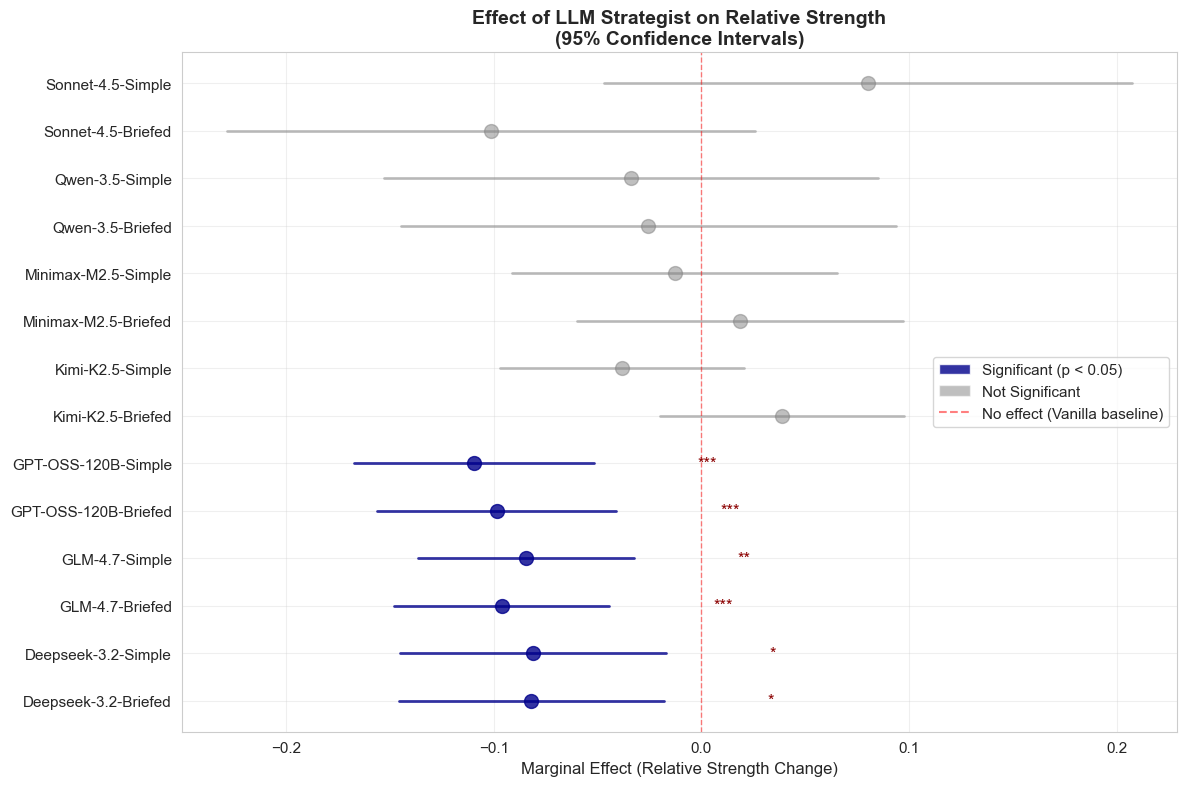

In [ ]:
# =====================================================
# VISUALIZATION 1: LLM STRATEGIST EFFECTS
# =====================================================
# Create forest plot showing how LLM strategists affect score ratio
# compared to vanilla gameplay (no LLM strategist)

# Create forest plot for conditions with integrated summary
fig, ax = plot_forest_plot(
    condition_df, 
    title='Effect of LLM Strategist on Relative Strength\n(95% Confidence Intervals)',
    xlabel='Marginal Effect (Relative Strength Change)',
    color='darkblue',
    figsize=(12, 8),
    reference_line_label='No effect (Vanilla baseline)',
    use_prob_scale=False,  # Use raw scale for score ratio
    sort_alphabetically=True
)

plt.show()


Civilization Effects on Relative Strength
(Relative to Mean, 95% Confidence Intervals) SUMMARY

Baseline: Average of all civilization effect

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Mongolia                       -0.197 [-0.269, -0.126] ***
  Assyria                        -0.172 [-0.241, -0.102] ***
  Persia                         -0.156 [-0.220, -0.091] ***
  Denmark                        -0.154 [-0.224, -0.084] ***
  Japan                          -0.150 [-0.215, -0.086] ***
  Rome                           -0.139 [-0.206, -0.072] ***
  America                        -0.138 [-0.205, -0.072] ***
  England                        -0.120 [-0.197, -0.044] **
  Korea                          -0.119 [-0.193, -0.044] **
  Sweden                         -0.093 [-0.169, -0.018] *
  The Huns                       -0.079 [-0.149, -0.010] *
  The Celts                      +0.075 [+0.003, +0.147] *
  Spain                          +0.075 [+0.00

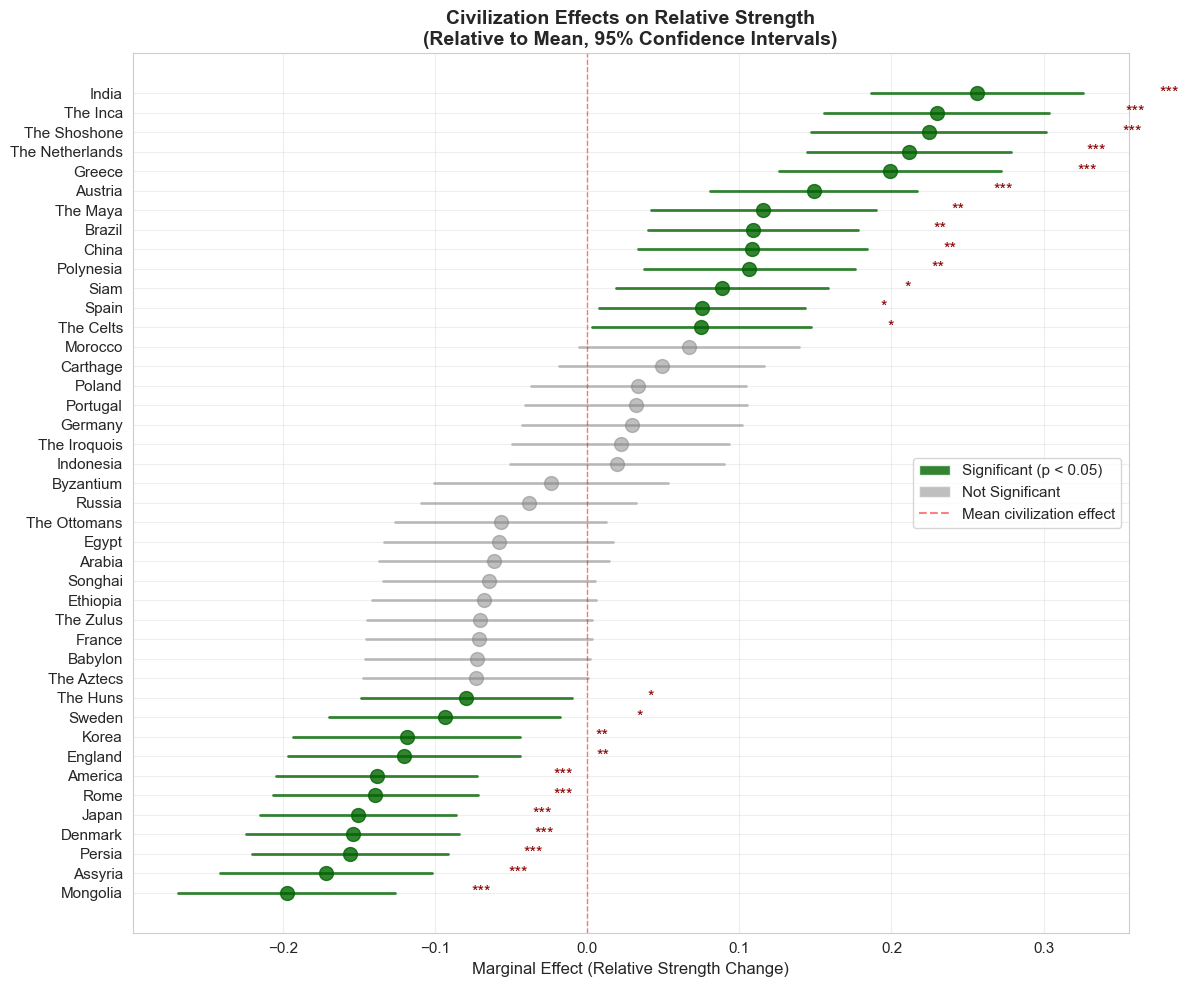

In [ ]:
# =====================================================
# VISUALIZATION 2: CIVILIZATION EFFECTS (RELATIVE TO MEAN)
# =====================================================
# Create forest plot showing civilization strength relative to the mean
# This approach uses the average civilization performance as the baseline

# Create forest plot for civilizations with integrated summary
fig, ax = plot_forest_plot(
    civ_df,
    title='Civilization Effects on Relative Strength\n(Relative to Mean, 95% Confidence Intervals)',
    xlabel='Marginal Effect (Relative Strength Change)',
    color='darkgreen',
    figsize=(12, 10),
    reference_line_label='Mean civilization effect',
    use_prob_scale=False,  # Use raw scale for score ratio
)

plt.show()

In [ ]:
# =====================================================
# CIVILIZATION FIXED EFFECTS: ADJUST FOR CIV ADVANTAGES
# =====================================================
# Extract civilization effects from the OLS model to adjust for civ advantages

# Create civilization effects lookup dictionary
civ_effects = {}
for var in civ_vars:
    # Extract civilization name from variable string
    # Format: "C(civilization, Sum)[S.CivName]"
    civ_name = var.split('[S.')[-1].rstrip(']')
    civ_effects[civ_name] = params[var]

# For the reference category (implied by Sum coding), calculate the negative sum
# Sum coding means all effects sum to zero
civ_effects['Venice'] = -sum(civ_effects.values())  # Venice is the missing civ

# Add adjusted_strength column to strength_df
# This removes the civilization advantage/disadvantage
strength_df['adjusted_strength'] = strength_df.apply(
    lambda row: row['relative_strength'] - civ_effects.get(row['civilization'], 0),
    axis=1
)
strength_df = strength_df[~strength_df['experiment'].isin(["observe-vanilla-standard"])]

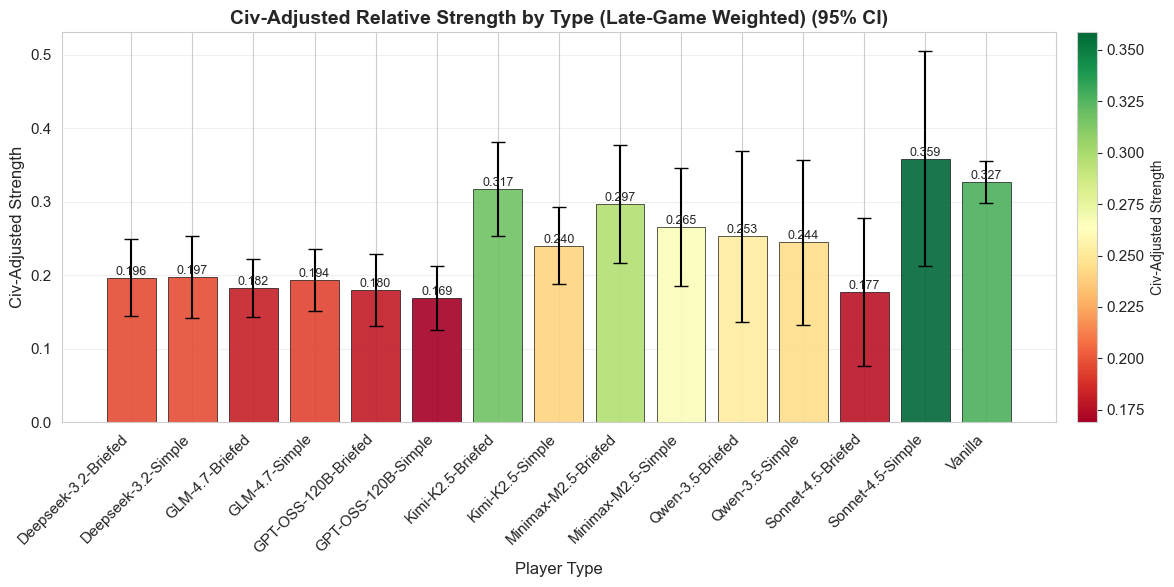

,Mean,Std,N
Deepseek-3.2-Briefed,0.196355,0.286228,115
Deepseek-3.2-Simple,0.197221,0.306437,115
GLM-4.7-Briefed,0.182187,0.270622,179
GLM-4.7-Simple,0.193799,0.286407,179
GPT-OSS-120B-Briefed,0.179814,0.296514,142
GPT-OSS-120B-Simple,0.168905,0.264217,142
Kimi-K2.5-Briefed,0.317265,0.379916,137
Kimi-K2.5-Simple,0.240345,0.313424,137
Minimax-M2.5-Briefed,0.297015,0.356269,75
Minimax-M2.5-Simple,0.265483,0.352095,75


In [ ]:
# Plot bar chart of average weighted strength by player type
plot_bar_chart(
    strength_df,
    category_col='player_type',
    value_col='adjusted_strength',
    use_percentage=False,
    xlabel='Player Type',
    ylabel='Civ-Adjusted Strength',
    title='Civ-Adjusted Relative Strength by Type (Late-Game Weighted)',
    show_error_bars=True,
    confidence_level=0.95,
    value_format='{:.3f}',
    rotation=45,
    colormap='RdYlGn',
    figsize=(12, 6)
)

In [ ]:
# =====================================================
# RATING CALCULATION: USING PLACKETT-LUCE MLE (R)
# =====================================================
# Calculate player ratings using R's PlackettLuce package
# via batch maximum likelihood estimation (order-independent)

from rating_system import calculate_ratings, compare_with_ols

# Calculate ratings with Plackett-Luce MLE
rating_summary_df = calculate_ratings(
    strength_df,
    verbose=True
)

CALCULATING RATINGS USING PLACKETT-LUCE MLE

Model: Plackett-Luce (direct maximum likelihood)
Baseline rating (Vanilla): μ=25.0
Total games: 264
Player types: 15

Optimizing...
Optimization converged: True
Log-likelihood: -2781.07

RATING SUMMARY
Rank   Player Type               Rating (μ)      Sigma        Elo       
----------------------------------------------------------------------------
1      Sonnet-4.5-Simple                   25.25        0.717       1571
2      Kimi-K2.5-Briefed                   25.01        0.535       1504
3      Vanilla                             25.00        0.000       1500
4      Qwen-3.5-Briefed                    24.93        0.810       1484
5      Minimax-M2.5-Simple                 24.93        0.859       1483
6      Minimax-M2.5-Briefed                24.92        0.855       1482
7      Qwen-3.5-Simple                     24.86        0.814       1466
8      Kimi-K2.5-Simple                    24.80        0.727       1444
9      Deepseek-3.2

VALIDATION: OPENSKILL RATINGS vs OLS COEFFICIENTS

Comparison of ranking methods:

Player Type               Rank     Rating Dev   OLS Coef    
---------------------------------------------------------
Sonnet-4.5-Simple         1             25.25       0.0802
Kimi-K2.5-Briefed         2             25.01       0.0389
Vanilla                   3             25.00       0.0000
Qwen-3.5-Briefed          4             24.93      -0.0256
Minimax-M2.5-Simple       5             24.93      -0.0129
Minimax-M2.5-Briefed      6             24.92       0.0187
Qwen-3.5-Simple           7             24.86      -0.0339
Kimi-K2.5-Simple          8             24.80      -0.0380
Deepseek-3.2-Briefed      9             24.78      -0.0820
GLM-4.7-Briefed           10            24.75      -0.0962
GLM-4.7-Simple            11            24.71      -0.0846
Sonnet-4.5-Briefed        12            24.68      -0.1013
GPT-OSS-120B-Simple       13            24.65      -0.1095
GPT-OSS-120B-Briefed      14   

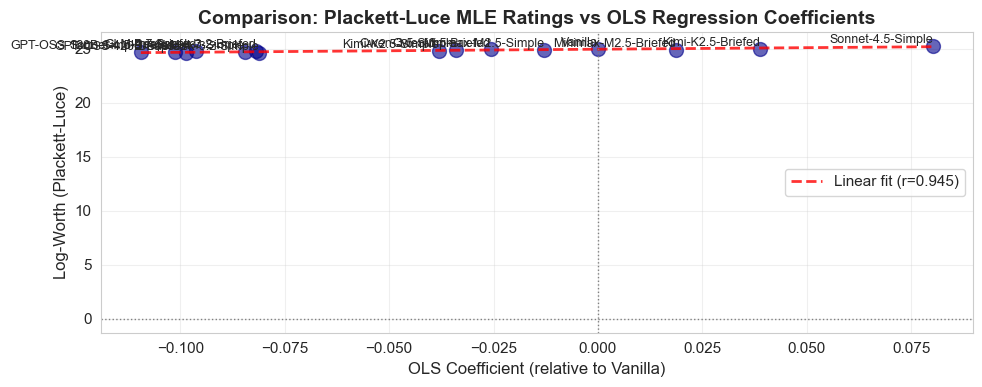

In [ ]:
# =====================================================
# VALIDATION: RATING vs OLS COMPARISON
# =====================================================
# Compare Plackett-Luce ratings to OLS regression coefficients

comparison_df = compare_with_ols(rating_summary_df, model, baseline_type='Vanilla', baseline_rating=0.0, verbose=True)

# Scatter plot visualization
valid_comparison = comparison_df.dropna()
if len(valid_comparison) > 1:
    correlation = valid_comparison['rating_deviation'].corr(valid_comparison['ols_coefficient'])
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(valid_comparison['ols_coefficient'], valid_comparison['rating_deviation'], 
               s=100, alpha=0.6, color='darkblue')
    
    # Add labels for each point
    for _, row in valid_comparison.iterrows():
        ax.annotate(row['player_type'], 
                   (row['ols_coefficient'], row['rating_deviation']),
                   fontsize=9, ha='right', va='bottom')
    
    # Add trend line
    z = np.polyfit(valid_comparison['ols_coefficient'], valid_comparison['rating_deviation'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid_comparison['ols_coefficient'].min(), 
                        valid_comparison['ols_coefficient'].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label=f'Linear fit (r={correlation:.3f})')
    
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.axvline(0, color='gray', linestyle=':', linewidth=1)
    
    ax.set_xlabel('OLS Coefficient (relative to Vanilla)', fontsize=12)
    ax.set_ylabel('Log-Worth (Plackett-Luce)', fontsize=12)
    ax.set_title('Comparison: Plackett-Luce MLE Ratings vs OLS Regression Coefficients', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

HEAD-TO-HEAD MATCHUP MATRIX (EMPIRICAL)

Matrix dimensions: 15x15
Player types: 15
Total games analyzed: 264

Interpretation:
  - Rows: Player A
  - Columns: Player B
  - Value: Empirical P(A has higher adjusted strength than B)
  - P-values: One-way ANOVA testing if mean strengths differ

Sample sizes:
  Deepseek-3.2-Briefed vs Vanilla: 230 matchups
  Deepseek-3.2-Simple vs Vanilla: 230 matchups
  GLM-4.7-Briefed vs Vanilla: 498 matchups
  GLM-4.7-Simple vs Vanilla: 498 matchups
  GPT-OSS-120B-Briefed vs Vanilla: 444 matchups
  GPT-OSS-120B-Simple vs Vanilla: 444 matchups
  Kimi-K2.5-Briefed vs Vanilla: 274 matchups
  Kimi-K2.5-Simple vs Vanilla: 274 matchups
  Minimax-M2.5-Briefed vs Vanilla: 150 matchups
  Minimax-M2.5-Simple vs Vanilla: 150 matchups
  Qwen-3.5-Briefed vs Vanilla: 64 matchups
  Qwen-3.5-Simple vs Vanilla: 64 matchups
  Sonnet-4.5-Briefed vs Vanilla: 92 matchups
  Sonnet-4.5-Simple vs Vanilla: 92 matchups


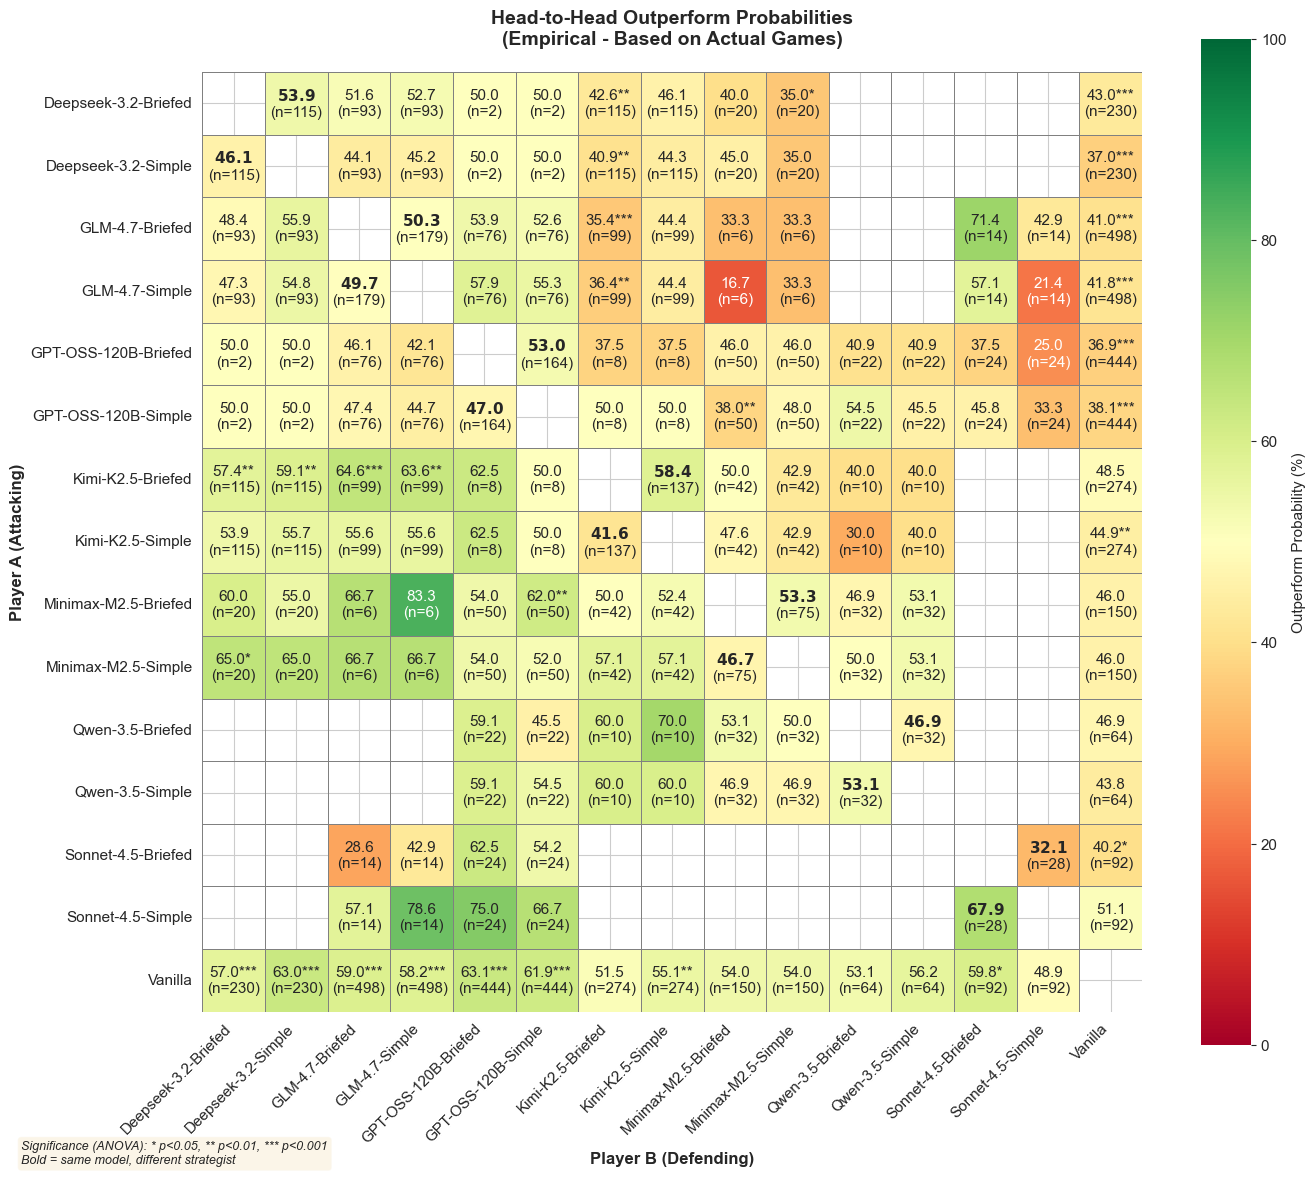


MATCHUP ANALYSIS

Deepseek-3.2-Briefed:
  vs Vanilla: 43.0% (n=230)
  Best matchup: vs Deepseek-3.2-Simple (53.9%, n=115)
  Worst matchup: vs Minimax-M2.5-Simple (35.0%, n=20)

Deepseek-3.2-Simple:
  vs Vanilla: 37.0% (n=230)
  Best matchup: vs GPT-OSS-120B-Briefed (50.0%, n=2)
  Worst matchup: vs Minimax-M2.5-Simple (35.0%, n=20)

GLM-4.7-Briefed:
  vs Vanilla: 41.0% (n=498)
  Best matchup: vs Sonnet-4.5-Briefed (71.4%, n=14)
  Worst matchup: vs Minimax-M2.5-Briefed (33.3%, n=6)

GLM-4.7-Simple:
  vs Vanilla: 41.8% (n=498)
  Best matchup: vs GPT-OSS-120B-Briefed (57.9%, n=76)
  Worst matchup: vs Minimax-M2.5-Briefed (16.7%, n=6)

GPT-OSS-120B-Briefed:
  vs Vanilla: 36.9% (n=444)
  Best matchup: vs GPT-OSS-120B-Simple (53.0%, n=164)
  Worst matchup: vs Sonnet-4.5-Simple (25.0%, n=24)

GPT-OSS-120B-Simple:
  vs Vanilla: 38.1% (n=444)
  Best matchup: vs Qwen-3.5-Briefed (54.5%, n=22)
  Worst matchup: vs Sonnet-4.5-Simple (33.3%, n=24)

Kimi-K2.5-Briefed:
  vs Vanilla: 48.5% (n=274)
  Be

In [ ]:
# =====================================================
# HEAD-TO-HEAD MATCHUP MATRIX
# =====================================================
# Calculate empirical pairwise outperform probabilities between all player types
# based on actual game data

from rating_system import create_matchup_matrix
from plot_utilities import plot_matchup_heatmap

# Create matchup matrix using actual game data from strength_df
matchup_matrix_df, count_matrix_df, pvalue_matrix_df = create_matchup_matrix(
    strength_df,
    verbose=True
)

# Visualize as heatmap with percentages and match counts
fig, ax = plot_matchup_heatmap(
    matchup_matrix_df,
    count_df=count_matrix_df,
    pvalue_df=pvalue_matrix_df,
    title="Head-to-Head Outperform Probabilities\n(Empirical - Based on Actual Games)",
    figsize=(14, 12),
    as_percentage=True
)

plt.show()

# Matchup analysis with Vanilla baseline
print("\n" + "=" * 60)
print("MATCHUP ANALYSIS")
print("=" * 60)

for player in matchup_matrix_df.index:
    if player == 'Vanilla':
        continue  # Skip baseline
    
    # Find best matchup (highest outperform probability against non-self)
    matchups = matchup_matrix_df.loc[player]
    matchups_filtered = matchups[matchups.index != player].dropna()
    
    if len(matchups_filtered) == 0:
        continue
    
    best_opponent = matchups_filtered.idxmax()
    best_prob = matchups_filtered.max()
    best_count = count_matrix_df.loc[player, best_opponent]
    
    worst_opponent = matchups_filtered.idxmin()
    worst_prob = matchups_filtered.min()
    worst_count = count_matrix_df.loc[player, worst_opponent]
    
    # Get matchup vs Vanilla
    vanilla_prob = matchup_matrix_df.loc[player, 'Vanilla']
    vanilla_count = count_matrix_df.loc[player, 'Vanilla']
    
    print(f"\n{player}:")
    if pd.notna(vanilla_prob):
        print(f"  vs Vanilla: {vanilla_prob*100:.1f}% (n={int(vanilla_count)})")
    else:
        print(f"  vs Vanilla: No data")
    print(f"  Best matchup: vs {best_opponent} ({best_prob*100:.1f}%, n={int(best_count)})")
    print(f"  Worst matchup: vs {worst_opponent} ({worst_prob*100:.1f}%, n={int(worst_count)})")

HEAD-TO-HEAD MATCHUP MATRIX (MEAN STRENGTH DIFFERENCE)

Matrix dimensions: 15x15
Player types: 15
Total games analyzed: 264

Interpretation:
  - Rows: Player A
  - Columns: Player B
  - Value: Mean(A_adjusted_strength - B_adjusted_strength)
  - Positive = A is stronger on average
  - P-values: One-sample t-test (H0: mean diff = 0)


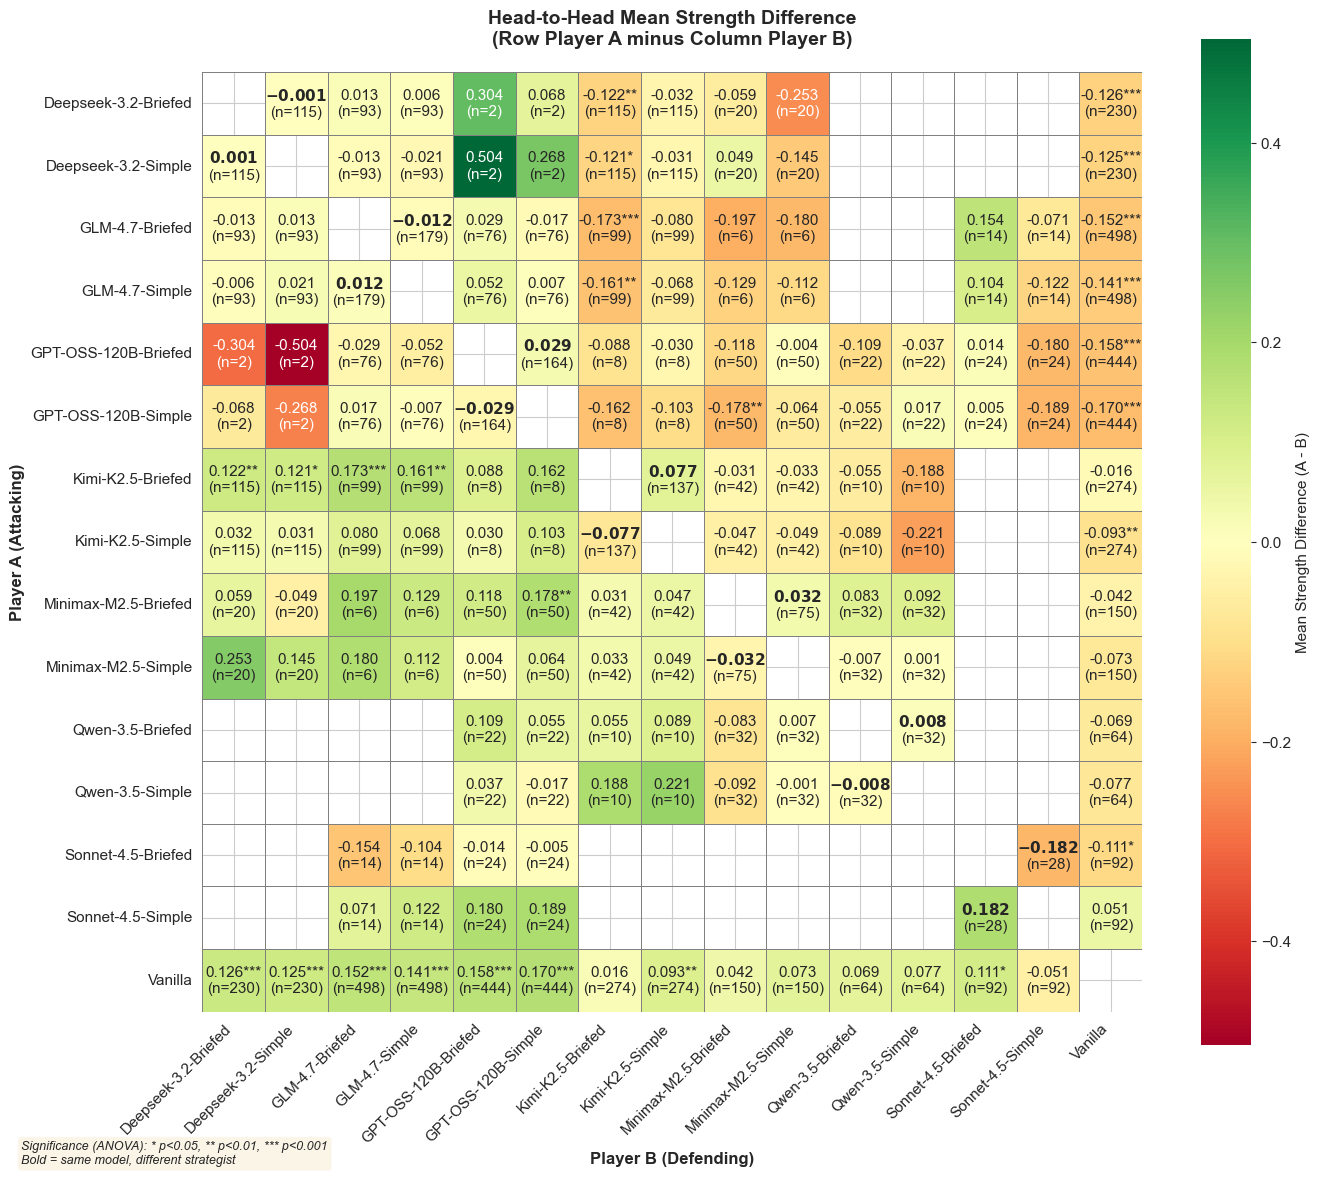


WIN-RATE vs MEAN-DIFFERENCE DISAGREEMENTS
Cases where win rate and mean difference point in opposite directions:

  Deepseek-3.2-Briefed vs Deepseek-3.2-Simple:
    Win rate: 53.9% | Mean diff: -0.0009 | n=115
  Deepseek-3.2-Simple vs Deepseek-3.2-Briefed:
    Win rate: 46.1% | Mean diff: +0.0009 | n=115
  Deepseek-3.2-Simple vs Minimax-M2.5-Briefed:
    Win rate: 45.0% | Mean diff: +0.0491 | n=20
  GLM-4.7-Briefed vs GLM-4.7-Simple:
    Win rate: 50.3% | Mean diff: -0.0116 | n=179
  GLM-4.7-Briefed vs GPT-OSS-120B-Simple:
    Win rate: 52.6% | Mean diff: -0.0171 | n=76
  GLM-4.7-Simple vs GLM-4.7-Briefed:
    Win rate: 49.7% | Mean diff: +0.0116 | n=179
  GPT-OSS-120B-Briefed vs Sonnet-4.5-Briefed:
    Win rate: 37.5% | Mean diff: +0.0135 | n=24
  GPT-OSS-120B-Simple vs GLM-4.7-Briefed:
    Win rate: 47.4% | Mean diff: +0.0171 | n=76
  GPT-OSS-120B-Simple vs Qwen-3.5-Briefed:
    Win rate: 54.5% | Mean diff: -0.0552 | n=22
  GPT-OSS-120B-Simple vs Qwen-3.5-Simple:
    Win rate: 45.5%

In [ ]:
# =====================================================
# HEAD-TO-HEAD MATCHUP MATRIX (MEAN STRENGTH DIFFERENCE)
# =====================================================
# Complement the win-rate matrix with mean strength differences.
# A player can win <50% of comparisons but still be stronger on average
# (e.g., winning by small margins, losing by large ones).

from rating_system import create_mean_matchup_matrix

mean_diff_df, mean_count_df, mean_pvalue_df = create_mean_matchup_matrix(
    strength_df,
    verbose=True
)

# Symmetric colormap range centered at 0
abs_max = np.nanmax(np.abs(mean_diff_df.values))

fig, ax = plot_matchup_heatmap(
    mean_diff_df,
    count_df=mean_count_df,
    pvalue_df=mean_pvalue_df,
    title="Head-to-Head Mean Strength Difference\n(Row Player A minus Column Player B)",
    figsize=(14, 12),
    as_percentage=False,
    vmin=-abs_max,
    vmax=abs_max,
    center=0,
    cbar_label='Mean Strength Difference (A - B)',
    annot_format='.3f'
)

plt.show()

# Compare win-rate vs mean-difference: flag disagreements
print("\n" + "=" * 60)
print("WIN-RATE vs MEAN-DIFFERENCE DISAGREEMENTS")
print("=" * 60)
print("Cases where win rate and mean difference point in opposite directions:\n")

found = False
for a in matchup_matrix_df.index:
    for b in matchup_matrix_df.columns:
        if a == b:
            continue
        wr = matchup_matrix_df.loc[a, b]
        md = mean_diff_df.loc[a, b]
        if pd.isna(wr) or pd.isna(md):
            continue
        # Win rate says A wins more often, but mean says A is weaker (or vice versa)
        if (wr > 0.5 and md < 0) or (wr < 0.5 and md > 0):
            n = int(mean_count_df.loc[a, b])
            found = True
            print(f"  {a} vs {b}:")
            print(f"    Win rate: {wr*100:.1f}% | Mean diff: {md:+.4f} | n={n}")

if not found:
    print("  None found — win rate and mean difference agree for all pairs.")


CIV-ADJUSTED WIN PROBABILITY: VALIDATION

Original mean: 0.1250
Adjusted mean: 0.1265

Original std: 0.1763
Adjusted std: 0.1833

Adjustment range: [-0.1975, 0.2564]
Mean adjustment magnitude: 0.1037


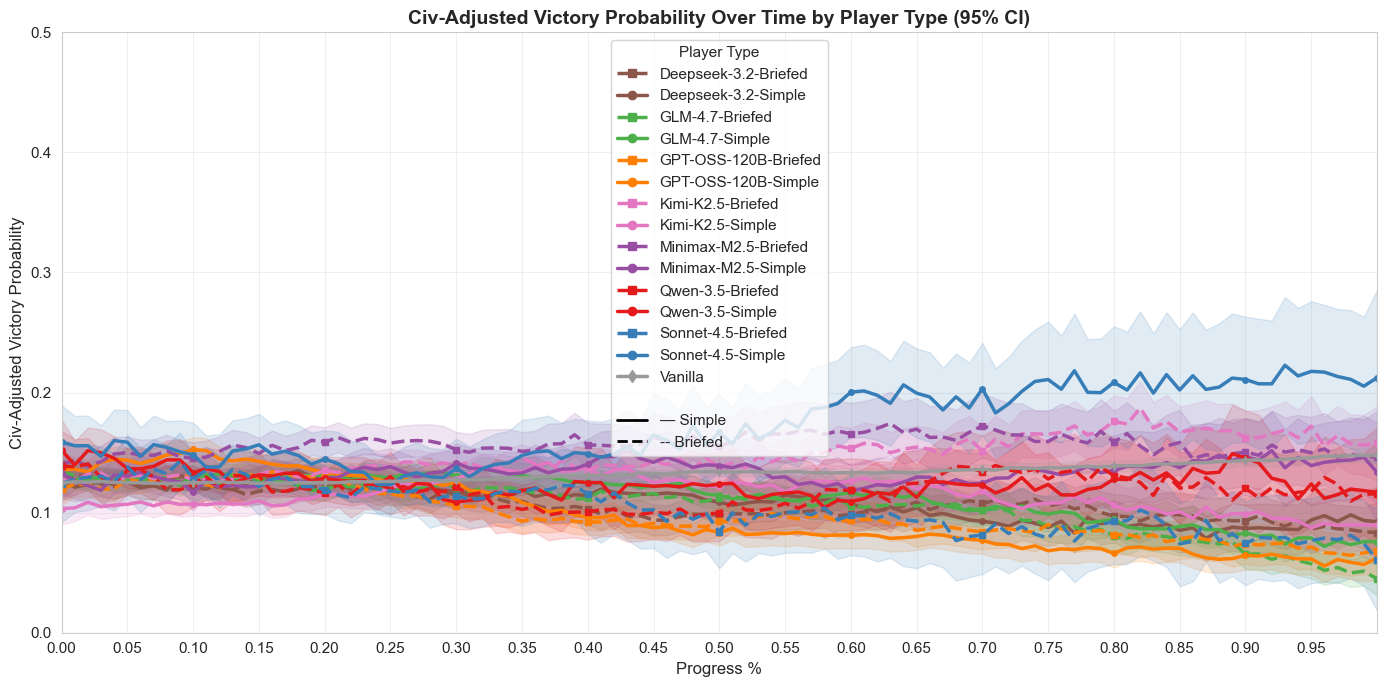

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,0.107,0.168,-0.256,1.034,-0.034779,-0.060
Deepseek-3.2-Simple,49080,0.108,0.177,-0.256,1.144,-0.046783,-0.076
GLM-4.7-Briefed,75725,0.105,0.157,-0.256,1.068,-0.070612,-0.130
GLM-4.7-Simple,75725,0.113,0.168,-0.256,1.086,-0.060022,-0.103
GPT-OSS-120B-Briefed,59705,0.098,0.165,-0.256,1.031,-0.062458,-0.109
GPT-OSS-120B-Simple,59705,0.097,0.140,-0.256,1.018,-0.098966,-0.203
Kimi-K2.5-Briefed,58275,0.148,0.200,-0.256,1.138,0.046305,0.067
Kimi-K2.5-Simple,58275,0.115,0.180,-0.256,1.093,-0.017015,-0.027
Minimax-M2.5-Briefed,31460,0.157,0.195,-0.253,0.999,0.005776,0.009
Minimax-M2.5-Simple,31460,0.134,0.207,-0.256,1.034,0.012468,0.017


In [ ]:
# =====================================================
# CIV-ADJUSTED VICTORY PROBABILITY OVER TIME
# =====================================================
# Apply civilization adjustments (from Cell 12) to predicted_win_probability
# and visualize how player types perform when civilization bias is removed

# Apply the same civ_effects from Cell 12 to predicted_win_probability
turn_df['civ_adjusted_win_prob'] = turn_df.apply(
    lambda row: row['predicted_win_probability'] - civ_effects.get(row['civilization'], 0),
    axis=1
)

# Validation checks
print("\n" + "=" * 60)
print("CIV-ADJUSTED WIN PROBABILITY: VALIDATION")
print("=" * 60)
print(f"\nOriginal mean: {turn_df['predicted_win_probability'].mean():.4f}")
print(f"Adjusted mean: {turn_df['civ_adjusted_win_prob'].mean():.4f}")
print(f"\nOriginal std: {turn_df['predicted_win_probability'].std():.4f}")
print(f"Adjusted std: {turn_df['civ_adjusted_win_prob'].std():.4f}")

adjustment_range = turn_df['predicted_win_probability'] - turn_df['civ_adjusted_win_prob']
print(f"\nAdjustment range: [{adjustment_range.min():.4f}, {adjustment_range.max():.4f}]")
print(f"Mean adjustment magnitude: {adjustment_range.abs().mean():.4f}")

# Plot civ-adjusted win probability over time
fig, ax = plot_metric_over_time(
    turn_df,
    metric_calculation=lambda df: df['civ_adjusted_win_prob'],
    title="Civ-Adjusted Victory Probability Over Time by Player Type",
    ylabel="Civ-Adjusted Victory Probability",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, 0.5)
)